# **Multi-Disease Classification from Chest X-Ray Images Using Deep Learning**

**Importing libraries**

In [ ]:
# Importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from PIL import Image
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive

import tensorflow as tf
from tensorflow import keras
import tensorflow.keras.backend as K
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet101V2, DenseNet121, EfficientNetB7
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import Sequence
from tensorflow.keras import regularizers
from huggingface_hub import hf_hub_download

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import StackingClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, f1_score, hamming_loss, precision_score, roc_auc_score

In [ ]:
# Testing the GPU

print("TensorFlow version:", tf.__version__)
print("GPUs Available:", tf.config.list_physical_devices('GPU'))
print("GPU Names:", [gpu.name for gpu in tf.config.list_physical_devices('GPU')])

# Quick GPU test
with tf.device('/GPU:0'):
    a = tf.random.normal([1000, 1000])
    b = tf.random.normal([1000, 1000])
    c = tf.matmul(a, b)
    print("\n✅ GPU is working!")

TensorFlow version: 2.19.0
GPUs Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU Names: ['/physical_device:GPU:0']

✅ GPU is working!


# **Data Loading & Pre-processing**

In [ ]:
# Defining the root directory for the images & CSV file
drive.mount('/content/drive')
print('Drive mounted successfully!')

data_dir = Path('/content/drive/MyDrive/BUAN_6341_Project/xray_data')  # Update this path as per your working directory
csv_file = data_dir / 'Data_Entry_2017.csv'

Mounted at /content/drive
Drive mounted successfully!


In [ ]:
# Loading the CSV file
data = pd.read_csv(csv_file)
data.shape

In [ ]:
# Defining the sample size & image size
sample_size = 10000
img_size = 224

# Defining disease labels
disease_labels = ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration',
                  'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax',
                  'Consolidation', 'Edema', 'Emphysema', 'Fibrosis',
                  'Pleural_Thickening', 'Hernia']

# Creating binary columns for stratification
for disease in disease_labels:
    data[disease] = data['Finding Labels'].str.contains(disease).astype(int)

# Sampling equal amounts from each disease
samples_per_disease = sample_size // len(disease_labels)

sampled_indices = set()
data_samples_list = []

for disease in disease_labels:
    disease_data = data[data[disease] == 1]

    if len(disease_data) >= samples_per_disease:
        disease_sample = disease_data.sample(n = samples_per_disease, random_state = 42)
    else:
        disease_sample = disease_data

    new_samples = disease_sample[~disease_sample.index.isin(sampled_indices)]
    data_samples_list.append(new_samples)
    sampled_indices.update(new_samples.index)

# Combine collected samples
data_sample = pd.concat(data_samples_list)

# Filling up the sample_size with random samples
remaining = sample_size - len(data_sample)
if remaining > 0:
    remaining_data = data[~data.index.isin(sampled_indices)].sample(n = remaining, random_state = 42)
    data_sample = pd.concat([data_sample, remaining_data])

data_sample = data_sample.sample(frac=1, random_state = 42).reset_index(drop = True)

# Verifying the sample
print(f"\n Sampled {len(data_sample)} images")
print("\nClass Distribution:")
for disease in disease_labels:
    count = data_sample[disease].sum()
    print(f"   {disease:20s}: {count:4d} ({count/len(data_sample)*100:5.1f}%)")

In [ ]:
# Pre-allocating arrays to avoid memory duplication
X = np.zeros((sample_size, img_size, img_size, 3), dtype=np.float32)
y = np.zeros((sample_size, 14), dtype=np.int8)
patient_ids = np.zeros((sample_size,), dtype=np.int64)

In [ ]:
# Loading the images & converting to numpy arrays
loaded_count = 0
skipped_count = 0

patient_ids = np.zeros((sample_size,), dtype=np.int64)

for idx, row in tqdm(data_sample.iterrows(), total=len(data_sample), desc='Loading...'):
    img_filename = row['Image Index']

    # Finding the image
    img_path = None
    for i in range(1, 13):
        potential_path = data_dir / f'images_{i:03d}' / 'images' / img_filename
        if potential_path.exists():
            img_path = potential_path
            break

    if img_path is None:
        skipped_count += 1
        continue

    try:
        img = Image.open(img_path).convert('RGB')
        img = img.resize((img_size, img_size))
        img_array = np.array(img, dtype=np.float32) / 255.0
        X[loaded_count] = img_array

        label_vec = [row[disease] for disease in disease_labels]
        y[loaded_count] = label_vec
        patient_ids[loaded_count] = row["Patient ID"]

        loaded_count += 1

    except Exception as e:
        skipped_count += 1
        continue

X = X[:loaded_count]
y = y[:loaded_count]
patient_ids = patient_ids[:loaded_count]

print(f'Skipped Count: {skipped_count}')
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

np.save('/content/drive/MyDrive/BUAN_6341_Project/xray_data/X_10k_224.npy', X)
np.save('/content/drive/MyDrive/BUAN_6341_Project/xray_data/y_10k_224.npy', y)
np.save('/content/drive/MyDrive/BUAN_6341_Project/xray_data/patient_ids_10k.npy', patient_ids)

print('Arrays saved successfully!')

In [ ]:
# Loading the preprocessed arrays
X = np.load(data_dir / 'X_10k_224.npy', mmap_mode=None)
y = np.load(data_dir / 'y_10k_224.npy', mmap_mode=None)
patient_ids = np.load(data_dir / 'patient_ids_10k.npy', mmap_mode=None)

print('Arrays loaded successfully!')

Arrays loaded successfully!


In [ ]:
# Defining disease labels separately
disease_labels = ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration',
                  'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax',
                  'Consolidation', 'Edema', 'Emphysema', 'Fibrosis',
                  'Pleural_Thickening', 'Hernia']

In [ ]:
# Group Shuffle Split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=patient_ids))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print("X_train shape", X_train.shape, "y_train shape", y_train.shape)
print("X_test shape", X_test.shape, "y_test shape", y_test.shape)

X_train shape (7909, 224, 224, 3) y_train shape (7909, 14)
X_test shape (2091, 224, 224, 3) y_test shape (2091, 14)


In [ ]:
# Leakage Check
assert set(patient_ids[train_idx]).isdisjoint(set(patient_ids[test_idx]))

In [ ]:
# Defining the loss function that accounts for extreme class imbalance
def weighted_binary_crossentropy(pos_weight=2.0):
    def loss(y_true, y_pred):
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1 - epsilon)

        # BCE with positive class weighting
        bce = -(pos_weight * y_true * K.log(y_pred) + (1 - y_true) * K.log(1 - y_pred))

        return K.mean(K.sum(bce, axis=-1))
    return loss

# **Model Development**

1. ResNet101V2

In [ ]:
# Defining the base model for ResNet101V2
base_resnet = ResNet101V2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_resnet.trainable = False

In [ ]:
# Defining the model architecture
model_resnet = models.Sequential([
    base_resnet,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(14, activation='sigmoid')
])

# Compile with focal loss
model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss = weighted_binary_crossentropy(pos_weight=2.0),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

In [ ]:
# Getting the model summary
print('ResNet101V2 Model Summary:')
model_resnet.summary()

ResNet101V2 Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet101v2 (Functional)        │ (None, 7, 7, 2048)     │    42,626,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 14)             │         3,598 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,810,574 (167.12 MB)

 Trainable params: 1,184,014 (4.52 MB)

 Non-trainable params: 42,626,560 (162.61 MB)

In [ ]:
# Training the model
resnet_history = model_resnet.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    callbacks=[
        EarlyStopping(patience=7, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(patience=3, factor=0.5, verbose=1)
    ],
    verbose=1
)

Epoch 1/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 64s 403ms/step - accuracy: 0.1045 - auc: 0.5474 - loss: 10.9943 - val_accuracy: 0.1618 - val_auc: 0.6667 - val_loss: 8.0894 - learning_rate: 1.0000e-04
Epoch 2/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.1528 - auc: 0.6088 - loss: 8.7897 - val_accuracy: 0.1852 - val_auc: 0.6838 - val_loss: 7.9935 - learning_rate: 1.0000e-04
Epoch 3/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.1599 - auc: 0.6356 - loss: 8.5256 - val_accuracy: 0.1909 - val_auc: 0.6947 - val_loss: 7.8915 - learning_rate: 1.0000e-04
Epoch 4/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.1698 - auc: 0.6568 - loss: 8.2477 - val_accuracy: 0.1877 - val_auc: 0.7042 - val_loss: 7.8409 - learning_rate: 1.0000e-04
Epoch 5/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.1806 - auc: 0.6641 - loss: 8.2409 - val_accuracy: 0.1941 - val_auc: 0.7112 - val_loss: 7.7981 - learning_rate: 1.0000e-04
Epoch 6/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy:

2. DenseNet121

In [ ]:
# Defining the base model for DenseNet121
base_densenet = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_densenet.trainable = False

In [ ]:
# Defining the model architecture
model_densenet = models.Sequential([
    base_densenet,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(14, activation='sigmoid')
])

model_densenet.compile(optimizer = tf.keras.optimizers.Adam(learning_rate = 0.0001),
                       loss = weighted_binary_crossentropy(pos_weight=2.0), metrics = ['accuracy', tf.keras.metrics.AUC(name='auc')])

In [ ]:
# Getting the model summary
print('DenseNet121 Model Summary:')
model_densenet.summary()

DenseNet121 Model Summary:


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 14)             │         3,598 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,697,230 (29.36 MB)

 Trainable params: 659,726 (2.52 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
# Training the model
densenet_history = model_densenet.fit(X_train, y_train, validation_split = 0.2,
                                      epochs = 30,batch_size = 64,
                                      callbacks = [EarlyStopping(patience = 7, restore_best_weights = True),
                                              ReduceLROnPlateau(patience = 3, factor = 0.5)],
                                      verbose = 1)

Epoch 1/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 65s 417ms/step - accuracy: 0.0897 - auc: 0.5278 - loss: 11.0513 - val_accuracy: 0.1625 - val_auc: 0.6573 - val_loss: 8.1496 - learning_rate: 1.0000e-04
Epoch 2/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.1450 - auc: 0.6086 - loss: 8.6953 - val_accuracy: 0.1732 - val_auc: 0.6760 - val_loss: 8.0111 - learning_rate: 1.0000e-04
Epoch 3/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.1572 - auc: 0.6303 - loss: 8.4015 - val_accuracy: 0.1757 - val_auc: 0.6891 - val_loss: 7.9457 - learning_rate: 1.0000e-04
Epoch 4/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.1562 - auc: 0.6432 - loss: 8.3315 - val_accuracy: 0.1707 - val_auc: 0.6965 - val_loss: 7.8954 - learning_rate: 1.0000e-04
Epoch 5/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.1735 - auc: 0.6562 - loss: 8.2470 - val_accuracy: 0.1839 - val_auc: 0.7028 - val_loss: 7.8511 - learning_rate: 1.0000e-04
Epoch 6/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy:

3. EfficientNetB7

In [ ]:
# Reverting back to raw image format for EfficientNet
X_train_eff = X_train * 255.0
X_test_eff = X_test * 255.0

In [ ]:
# Defining the base model for EfficientNetB3
base_efficientnet = EfficientNetB7(weights='imagenet', include_top = False, input_shape = (224, 224, 3))
base_efficientnet.trainable = False

258076736/258076736 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step


In [ ]:
# Defining the model architecture
model_efficientnet = models.Sequential([
    base_efficientnet,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(14, activation='sigmoid')
])

model_efficientnet.compile(optimizer = tf.keras.optimizers.Adam(learning_rate = 0.0001),
                           loss = weighted_binary_crossentropy(pos_weight=2.0), metrics = ['accuracy', tf.keras.metrics.AUC(name='auc')])

In [ ]:
# Getting the model summary
print('EfficientNetB3 Model Summary:')
model_efficientnet.summary()

EfficientNetB3 Model Summary:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb7 (Functional)     │ (None, 7, 7, 2560)     │    64,097,687 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2560)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │     1,311,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 14)             │         3,598 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,543,845 (250.03 MB)

 Trainable params: 1,446,158 (5.52 MB)

 Non-trainable params: 64,097,687 (244.51 MB)

In [ ]:
# Training the model
efficientnet_history = model_efficientnet.fit(X_train_eff, y_train, validation_split = 0.2,
                                              epochs = 30, batch_size = 32,
                                              callbacks = [EarlyStopping(patience = 7, restore_best_weights = True),
                                                           ReduceLROnPlateau(patience = 3, factor = 0.5)],
                                              verbose = 1)

Epoch 1/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 250s 728ms/step - accuracy: 0.1205 - auc: 0.5787 - loss: 9.1199 - val_accuracy: 0.1953 - val_auc: 0.7003 - val_loss: 7.8962 - learning_rate: 1.0000e-04
Epoch 2/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 13s 66ms/step - accuracy: 0.1723 - auc: 0.6553 - loss: 8.2584 - val_accuracy: 0.2048 - val_auc: 0.7135 - val_loss: 7.7391 - learning_rate: 1.0000e-04
Epoch 3/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 13s 66ms/step - accuracy: 0.1876 - auc: 0.6711 - loss: 8.1027 - val_accuracy: 0.2118 - val_auc: 0.7268 - val_loss: 7.6341 - learning_rate: 1.0000e-04
Epoch 4/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 13s 66ms/step - accuracy: 0.1880 - auc: 0.6880 - loss: 7.9701 - val_accuracy: 0.2137 - val_auc: 0.7314 - val_loss: 7.5787 - learning_rate: 1.0000e-04
Epoch 5/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 13s 66ms/step - accuracy: 0.1961 - auc: 0.6967 - loss: 7.9129 - val_accuracy: 0.2219 - val_auc: 0.7352 - val_loss: 7.5433 - learning_rate: 1.0000e-04
Epoch 6/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 13s 66ms

# **Model Evaluation**

1. ResNet101V2

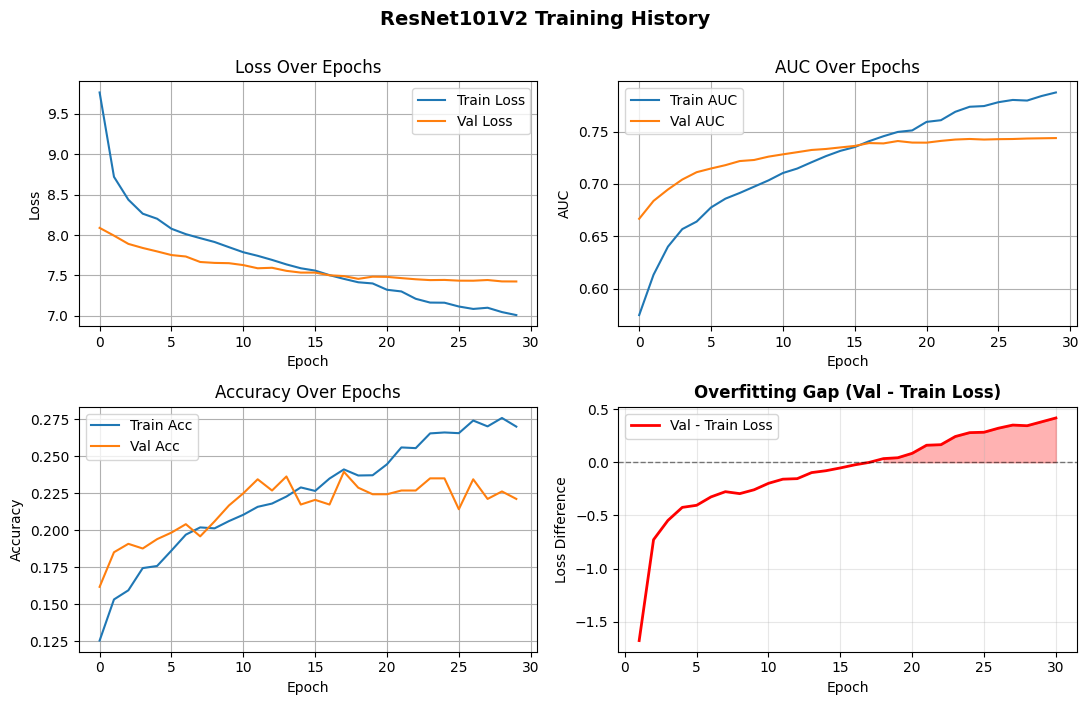

TRAINING SUMMARY
Total epochs trained: 30

Final Metrics:
  Train Loss: 7.0098
  Val Loss:   7.4260
  Train AUC:  0.7873
  Val AUC:    0.7437
  Train Acc:  0.2701
  Val Acc:    0.2212


In [ ]:
# ResNet101V2 Training Summary

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

# 1. Loss
axes[0, 0].plot(resnet_history.history['loss'], label='Train Loss')
axes[0, 0].plot(resnet_history.history['val_loss'], label='Val Loss')
axes[0, 0].set_title('Loss Over Epochs')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# 2. AUC
axes[0, 1].plot(resnet_history.history['auc'], label='Train AUC')
axes[0, 1].plot(resnet_history.history['val_auc'], label='Val AUC')
axes[0, 1].set_title('AUC Over Epochs')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('AUC')
axes[0, 1].legend()
axes[0, 1].grid(True)

# 3. Accuracy
axes[1, 0].plot(resnet_history.history['accuracy'], label='Train Acc')
axes[1, 0].plot(resnet_history.history['val_accuracy'], label='Val Acc')
axes[1, 0].set_title('Accuracy Over Epochs')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True)

# 4. Train vs Val Loss Gap (To detect Overfitting)
epochs = range(1, len(resnet_history.history['loss']) + 1)
loss_gap = np.array(resnet_history.history['val_loss']) - np.array(resnet_history.history['loss'])
axes[1, 1].plot(epochs, loss_gap, label='Val - Train Loss', linewidth=2, color='red')
axes[1, 1].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1, 1].set_title('Overfitting Gap (Val - Train Loss)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss Difference')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].fill_between(epochs, 0, loss_gap, where=(loss_gap > 0), alpha=0.3, color='red', label='Overfitting')

plt.suptitle('ResNet101V2 Training History', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Printing the summary
print("="*80)
print("TRAINING SUMMARY")
print("="*80)
print(f"Total epochs trained: {len(resnet_history.history['loss'])}")
print(f"\nFinal Metrics:")
print(f"  Train Loss: {resnet_history.history['loss'][-1]:.4f}")
print(f"  Val Loss:   {resnet_history.history['val_loss'][-1]:.4f}")
print(f"  Train AUC:  {resnet_history.history['auc'][-1]:.4f}")
print(f"  Val AUC:    {resnet_history.history['val_auc'][-1]:.4f}")
print(f"  Train Acc:  {resnet_history.history['accuracy'][-1]:.4f}")
print(f"  Val Acc:    {resnet_history.history['val_accuracy'][-1]:.4f}")
print("="*80)

In [ ]:
# ResNet101V2 Model Evaluation

# Getting predictions
pred_probs_resnet = model_resnet.predict(X_test, batch_size=128, verbose=1)

# Testing different thresholds
results_resnet = []

for threshold in [0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]:

  y_pred_resnet = (pred_probs_resnet > threshold).astype(int)

  # Calculating the metrics per disease
  f1_per_dis_resnet = f1_score(y_test, y_pred_resnet, average = None, zero_division = 0)
  precision_per_dis_resnet = precision_score(y_test, y_pred_resnet, average = None, zero_division = 0)
  recall_per_dis_resnet = recall_score(y_test, y_pred_resnet, average = None, zero_division = 0)
  pred_per_dis_resnet = y_pred_resnet.sum(axis = 0)

  # Calculating the Macro averages
  f1_macro_resnet = f1_per_dis_resnet.mean()
  precision_macro_resnet = precision_per_dis_resnet.mean()
  recall_macro_resnet = recall_per_dis_resnet.mean()
  accuracy_resnet = accuracy_score(y_test, y_pred_resnet)
  hamming_resnet = hamming_loss(y_test, y_pred_resnet)

  # Calculating the AUC
  auc_per_dis_resnet = []

  for i in range(y_test.shape[1]):
    try:
      auc_resnet = roc_auc_score(y_test[:, i], pred_probs_resnet[:, i])
      auc_per_dis_resnet.append(auc_resnet)
    except:
      auc_per_dis_resnet.append(0.5)

  auc_macro_resnet = np.mean(auc_per_dis_resnet)

  # Calculating the prediction counts
  pred_total_resnet = y_pred_resnet.sum()
  actual_total = y_test.sum()

  # Printing the results
  print("Macro-averaged Metrics")
  print(f"Evaluation threshold = {threshold:.2f}")
  print(f"F1 Score:       {f1_macro_resnet:.4f}")
  print(f"Precision:      {precision_macro_resnet:.4f}")
  print(f"Recall:         {recall_macro_resnet:.4f}")
  print(f"Accuracy:       {accuracy_resnet:.2f}")
  print(f"Hamming Loss:   {hamming_resnet:.4f}")
  print(f"AUC:            {auc_macro_resnet:.4f}")
  print(f"Predicted:      {pred_total_resnet}/{actual_total} (ratio={pred_total_resnet/actual_total:.2f})")

  print("Per Disease Metrics")
  print(f"{'Disease':<20} {'F1':>8} {'Precision':>10} {'Recall':>8} {'AUC':>8}")

  for i, disease in enumerate(disease_labels):
    print(f"{disease:<20} {f1_per_dis_resnet[i]:>8.4f} {precision_per_dis_resnet[i]:>10.4f} {recall_per_dis_resnet[i]:>8.4f} {auc_per_dis_resnet[i]:>8.4f}")

    results_resnet.append({
        'Threshold': threshold,
        'F1': f1_macro_resnet,
        'Precision': precision_macro_resnet,
        'Recall': recall_macro_resnet,
        'Accuracy': accuracy_resnet,
        'Hamming Loss': hamming_resnet,
        'AUC': auc_macro_resnet,
    })

# Finding the best threshold
df_summary_resnet = pd.DataFrame(results_resnet)
best_idx_resnet = df_summary_resnet['F1'].idxmax()
best_result_resnet = df_summary_resnet.iloc[best_idx_resnet]

print("\n")
print("Best Threshold")
print(f"Threshold: {best_result_resnet['Threshold']:.2f}")
print(f"F1 Score: {best_result_resnet['F1']:.4f}")
print(f"Precision: {best_result_resnet['Precision']:.4f}")
print(f"Recall: {best_result_resnet['Recall']:.4f}")
print(f"Accuracy: {best_result_resnet['Accuracy']:.2f}")
print(f"Hamming Loss: {best_result_resnet['Hamming Loss']:.4f}")
print(f"AUC: {best_result_resnet['AUC']:.4f}")

17/17 ━━━━━━━━━━━━━━━━━━━━ 28s 883ms/step
Macro-averaged Metrics
Evaluation threshold = 0.15
F1 Score:       0.2843
Precision:      0.1740
Recall:         0.8120
Accuracy:       0.00
Hamming Loss:   0.5318
AUC:            0.6946
Predicted:      18592/3961 (ratio=4.69)
Per Disease Metrics
Disease                    F1  Precision   Recall      AUC
Atelectasis            0.3707     0.2288   0.9755   0.6697
Cardiomegaly           0.2496     0.1519   0.6995   0.7137
Effusion               0.4396     0.2843   0.9690   0.6887
Infiltration           0.4638     0.3019   1.0000   0.6504
Mass                   0.2459     0.1418   0.9236   0.6250
Nodule                 0.2678     0.1555   0.9655   0.6664
Pneumonia              0.1905     0.1119   0.6383   0.6019
Pneumothorax           0.2874     0.1723   0.8651   0.7568
Consolidation          0.2685     0.1610   0.8078   0.6475
Edema                  0.3012     0.1848   0.8131   0.8041
Emphysema              0.2875     0.1760   0.7837   0.7650
Fib

2. DenseNet121

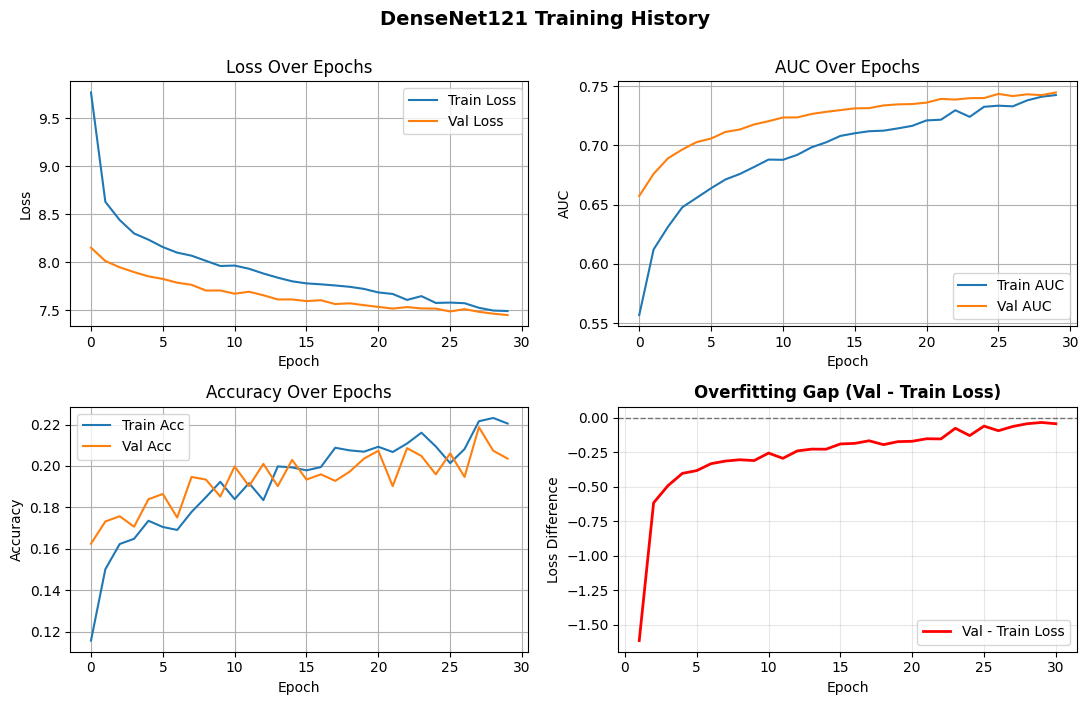

TRAINING SUMMARY
Total epochs trained: 30

Final Metrics:
  Train Loss: 7.4898
  Val Loss:   7.4477
  Train AUC:  0.7424
  Val AUC:    0.7446
  Train Acc:  0.2205
  Val Acc:    0.2035


In [ ]:
# DenseNet121 Training Summary

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

# 1. Loss
axes[0, 0].plot(densenet_history.history['loss'], label='Train Loss')
axes[0, 0].plot(densenet_history.history['val_loss'], label='Val Loss')
axes[0, 0].set_title('Loss Over Epochs')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# 2. AUC
axes[0, 1].plot(densenet_history.history['auc'], label='Train AUC')
axes[0, 1].plot(densenet_history.history['val_auc'], label='Val AUC')
axes[0, 1].set_title('AUC Over Epochs')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('AUC')
axes[0, 1].legend()
axes[0, 1].grid(True)

# 3. Accuracy
axes[1, 0].plot(densenet_history.history['accuracy'], label='Train Acc')
axes[1, 0].plot(densenet_history.history['val_accuracy'], label='Val Acc')
axes[1, 0].set_title('Accuracy Over Epochs')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True)

# 4. Train vs Val Loss Gap (To detect Overfitting)
epochs = range(1, len(densenet_history.history['loss']) + 1)
loss_gap = np.array(densenet_history.history['val_loss']) - np.array(densenet_history.history['loss'])
axes[1, 1].plot(epochs, loss_gap, label='Val - Train Loss', linewidth=2, color='red')
axes[1, 1].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1, 1].set_title('Overfitting Gap (Val - Train Loss)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss Difference')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].fill_between(epochs, 0, loss_gap, where=(loss_gap > 0), alpha=0.3, color='red', label='Overfitting')

plt.suptitle('DenseNet121 Training History', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Printing the summary
print("="*80)
print("TRAINING SUMMARY")
print("="*80)
print(f"Total epochs trained: {len(densenet_history.history['loss'])}")
print(f"\nFinal Metrics:")
print(f"  Train Loss: {densenet_history.history['loss'][-1]:.4f}")
print(f"  Val Loss:   {densenet_history.history['val_loss'][-1]:.4f}")
print(f"  Train AUC:  {densenet_history.history['auc'][-1]:.4f}")
print(f"  Val AUC:    {densenet_history.history['val_auc'][-1]:.4f}")
print(f"  Train Acc:  {densenet_history.history['accuracy'][-1]:.4f}")
print(f"  Val Acc:    {densenet_history.history['val_accuracy'][-1]:.4f}")
print("="*80)

In [ ]:
# DenseNet121 Model Evaluation

# Getting predictions
pred_probs_densenet = model_densenet.predict(X_test, batch_size=128, verbose=1)

# Testing different thresholds
results_densenet = []

for threshold in [0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]:

  y_pred_densenet = (pred_probs_densenet > threshold).astype(int)

  # Calculating the metrics per disease
  f1_per_dis_densenet = f1_score(y_test, y_pred_densenet, average = None, zero_division = 0)
  precision_per_dis_densenet = precision_score(y_test, y_pred_densenet, average = None, zero_division = 0)
  recall_per_dis_densenet = recall_score(y_test, y_pred_densenet, average = None, zero_division = 0)
  pred_per_dis_densenet = y_pred_densenet.sum(axis = 0)

  # Calculating the Macro averages
  f1_macro_densenet = f1_per_dis_densenet.mean()
  precision_macro_densenet = precision_per_dis_densenet.mean()
  recall_macro_densenet = recall_per_dis_densenet.mean()
  accuracy_densenet = accuracy_score(y_test, y_pred_densenet)
  hamming_densenet = hamming_loss(y_test, y_pred_densenet)

  # Calculating the AUC
  auc_per_dis_densenet = []

  for i in range(y_test.shape[1]):
    try:
      auc_densenet = roc_auc_score(y_test[:, i], pred_probs_densenet[:, i])
      auc_per_dis_densenet.append(auc_densenet)
    except:
      auc_per_dis_densenet.append(0.5)

  auc_macro_densenet = np.mean(auc_per_dis_densenet)

  # Calculating the prediction counts
  pred_total_densenet = y_pred_densenet.sum()
  actual_total = y_test.sum()

  # Printing the results
  print("Macro-averaged Metrics")
  print(f"Evaluation threshold = {threshold:.2f}")
  print(f"F1 Score:       {f1_macro_densenet:.4f}")
  print(f"Precision:      {precision_macro_densenet:.4f}")
  print(f"Recall:         {recall_macro_densenet:.4f}")
  print(f"Accuracy:       {accuracy_densenet:.2f}")
  print(f"Hamming Loss:   {hamming_densenet:.4f}")
  print(f"AUC:            {auc_macro_densenet:.4f}")
  print(f"Predicted:      {pred_total_densenet}/{actual_total} (ratio={pred_total_densenet/actual_total:.2f})")

  print("Per Disease Metrics")
  print(f"{'Disease':<20} {'F1':>8} {'Precision':>10} {'Recall':>8} {'AUC':>8}")

  for i, disease in enumerate(disease_labels):
    print(f"{disease:<20} {f1_per_dis_densenet[i]:>8.4f} {precision_per_dis_densenet[i]:>10.4f} {recall_per_dis_densenet[i]:>8.4f} {auc_per_dis_densenet[i]:>8.4f}")

  results_densenet.append({
        'Threshold': threshold,
        'F1': f1_macro_densenet,
        'Precision': precision_macro_densenet,
        'Recall': recall_macro_densenet,
        'Accuracy': accuracy_densenet,
        'Hamming Loss': hamming_densenet,
        'AUC': auc_macro_densenet,
    })

# Finding the best threshold
df_summary_densenet = pd.DataFrame(results_densenet)
best_idx_densenet = df_summary_densenet['F1'].idxmax()
best_result_densenet = df_summary_densenet.iloc[best_idx_densenet]

print("\n")
print("Best Threshold")
print(f"Threshold: {best_result_densenet['Threshold']:.2f}")
print(f"F1 Score: {best_result_densenet['F1']:.4f}")
print(f"Precision: {best_result_densenet['Precision']:.4f}")
print(f"Recall: {best_result_densenet['Recall']:.4f}")
print(f"Accuracy: {best_result_densenet['Accuracy']:.2f}")
print(f"Hamming Loss: {best_result_densenet['Hamming Loss']:.4f}")
print(f"AUC: {best_result_densenet['AUC']:.4f}")

17/17 ━━━━━━━━━━━━━━━━━━━━ 26s 849ms/step
Macro-averaged Metrics
Evaluation threshold = 0.15
F1 Score:       0.2820
Precision:      0.1708
Recall:         0.8519
Accuracy:       0.00
Hamming Loss:   0.5609
AUC:            0.6973
Predicted:      19712/3961 (ratio=4.98)
Per Disease Metrics
Disease                    F1  Precision   Recall      AUC
Atelectasis            0.3636     0.2226   0.9933   0.6607
Cardiomegaly           0.2399     0.1388   0.8826   0.7268
Effusion               0.4306     0.2760   0.9799   0.6901
Infiltration           0.4636     0.3018   1.0000   0.6479
Mass                   0.2432     0.1392   0.9636   0.6064
Nodule                 0.2682     0.1560   0.9552   0.6654
Pneumonia              0.2072     0.1202   0.7500   0.6358
Pneumothorax           0.2697     0.1590   0.8889   0.7371
Consolidation          0.2763     0.1638   0.8826   0.6467
Edema                  0.2965     0.1794   0.8535   0.7857
Emphysema              0.2709     0.1640   0.7788   0.7622
Fib

3. EfficientNetB7

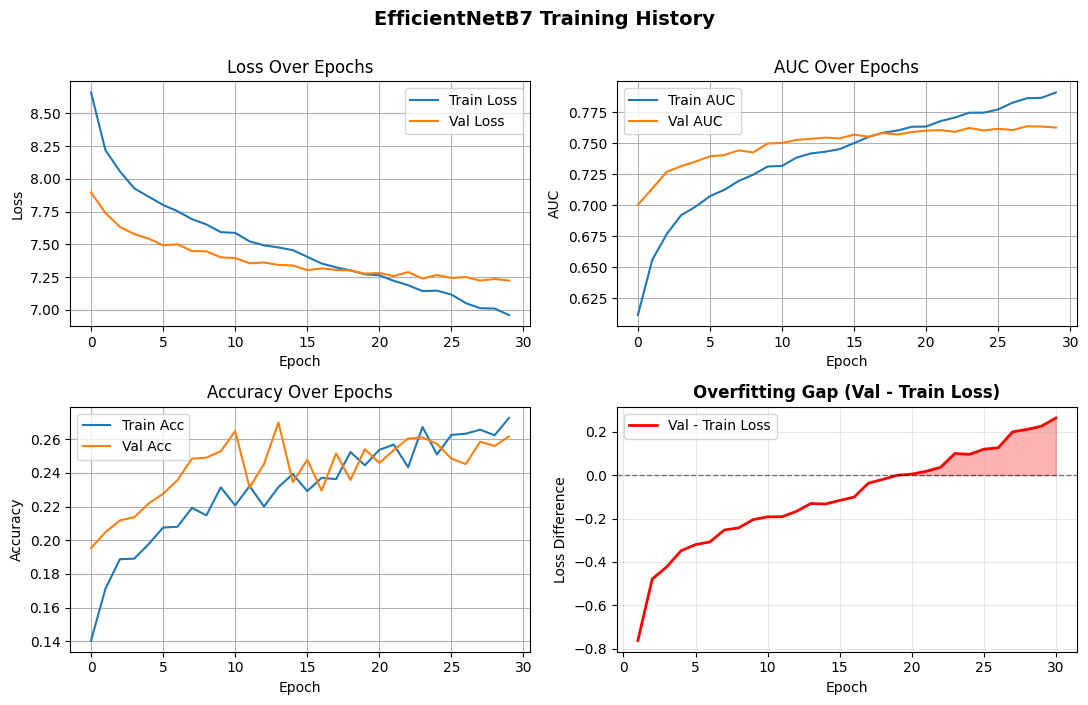

TRAINING SUMMARY
Total epochs trained: 30

Final Metrics:
  Train Loss: 6.9605
  Val Loss:   7.2239
  Train AUC:  0.7908
  Val AUC:    0.7625
  Train Acc:  0.2726
  Val Acc:    0.2617


In [ ]:
# 3. EfficientNetB7 Training Summary

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

# 1. Loss
axes[0, 0].plot(efficientnet_history.history['loss'], label='Train Loss')
axes[0, 0].plot(efficientnet_history.history['val_loss'], label='Val Loss')
axes[0, 0].set_title('Loss Over Epochs')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# 2. AUC
axes[0, 1].plot(efficientnet_history.history['auc'], label='Train AUC')
axes[0, 1].plot(efficientnet_history.history['val_auc'], label='Val AUC')
axes[0, 1].set_title('AUC Over Epochs')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('AUC')
axes[0, 1].legend()
axes[0, 1].grid(True)

# 3. Accuracy
axes[1, 0].plot(efficientnet_history.history['accuracy'], label='Train Acc')
axes[1, 0].plot(efficientnet_history.history['val_accuracy'], label='Val Acc')
axes[1, 0].set_title('Accuracy Over Epochs')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True)

# 4. Train vs Val Loss Gap (To detect Overfitting)
epochs = range(1, len(efficientnet_history.history['loss']) + 1)
loss_gap = np.array(efficientnet_history.history['val_loss']) - np.array(efficientnet_history.history['loss'])
axes[1, 1].plot(epochs, loss_gap, label='Val - Train Loss', linewidth=2, color='red')
axes[1, 1].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1, 1].set_title('Overfitting Gap (Val - Train Loss)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss Difference')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].fill_between(epochs, 0, loss_gap, where=(loss_gap > 0), alpha=0.3, color='red', label='Overfitting')

plt.suptitle('EfficientNetB7 Training History', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Printing the summary
print("="*80)
print("TRAINING SUMMARY")
print("="*80)
print(f"Total epochs trained: {len(efficientnet_history.history['loss'])}")
print(f"\nFinal Metrics:")
print(f"  Train Loss: {efficientnet_history.history['loss'][-1]:.4f}")
print(f"  Val Loss:   {efficientnet_history.history['val_loss'][-1]:.4f}")
print(f"  Train AUC:  {efficientnet_history.history['auc'][-1]:.4f}")
print(f"  Val AUC:    {efficientnet_history.history['val_auc'][-1]:.4f}")
print(f"  Train Acc:  {efficientnet_history.history['accuracy'][-1]:.4f}")
print(f"  Val Acc:    {efficientnet_history.history['val_accuracy'][-1]:.4f}")
print("="*80)

In [ ]:
# EfficientNetB7 Model Evaluation

# Getting predictions
pred_probs_efficientnet = model_efficientnet.predict(X_test_eff, batch_size=128, verbose=1)

# Testing different thresholds
results_efficientnet = []

for threshold in [0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]:

  y_pred_efficientnet = (pred_probs_efficientnet > threshold).astype(int)

  # Calculating the metrics per disease
  f1_per_dis_efficientnet = f1_score(y_test, y_pred_efficientnet, average = None, zero_division = 0)
  precision_per_dis_efficientnet = precision_score(y_test, y_pred_efficientnet, average = None, zero_division = 0)
  recall_per_dis_efficientnet = recall_score(y_test, y_pred_efficientnet, average = None, zero_division = 0)
  pred_per_dis_efficientnet = y_pred_efficientnet.sum(axis = 0)

  # Calculating the Macro averages
  f1_macro_efficientnet = f1_per_dis_efficientnet.mean()
  precision_macro_efficientnet = precision_per_dis_efficientnet.mean()
  recall_macro_efficientnet = recall_per_dis_efficientnet.mean()
  accuracy_efficientnet = accuracy_score(y_test, y_pred_efficientnet)
  hamming_efficientnet = hamming_loss(y_test, y_pred_efficientnet)

  # Calculating the AUC
  auc_per_dis_efficientnet = []

  for i in range(y_test.shape[1]):
    try:
      auc_efficientnet = roc_auc_score(y_test[:, i], pred_probs_efficientnet[:, i])
      auc_per_dis_efficientnet.append(auc_efficientnet)
    except:
      auc_per_dis_efficientnet.append(0.5)

  auc_macro_efficientnet = np.mean(auc_per_dis_efficientnet)

  # Calculating the prediction counts
  pred_total_efficientnet = y_pred_efficientnet.sum()
  actual_total = y_test.sum()

  # Printing the results
  print("Macro-averaged Metrics")
  print(f"Evaluation threshold = {threshold:.2f}")
  print(f"F1 Score:       {f1_macro_efficientnet:.4f}")
  print(f"Precision:      {precision_macro_efficientnet:.4f}")
  print(f"Recall:         {recall_macro_efficientnet:.4f}")
  print(f"Accuracy:       {accuracy_efficientnet:.2f}")
  print(f"Hamming Loss:   {hamming_efficientnet:.4f}")
  print(f"AUC:            {auc_macro_efficientnet:.4f}")
  print(f"Predicted:      {pred_total_efficientnet}/{actual_total} (ratio={pred_total_efficientnet/actual_total:.2f})")

  print("Per Disease Metrics")
  print(f"{'Disease':<20} {'F1':>8} {'Precision':>10} {'Recall':>8} {'AUC':>8}")

  for i, disease in enumerate(disease_labels):
    print(f"{disease:<20} {f1_per_dis_efficientnet[i]:>8.4f} {precision_per_dis_efficientnet[i]:>10.4f} {recall_per_dis_efficientnet[i]:>8.4f} {auc_per_dis_efficientnet[i]:>8.4f}")

  results_efficientnet.append({
        'Threshold': threshold,
        'F1': f1_macro_efficientnet,
        'Precision': precision_macro_efficientnet,
        'Recall': recall_macro_efficientnet,
        'Accuracy': accuracy_efficientnet,
        'Hamming Loss': hamming_efficientnet,
        'AUC': auc_macro_efficientnet,
    })

# Finding the best threshold
df_summary_efficientnet = pd.DataFrame(results_efficientnet)
best_idx_efficientnet = df_summary_efficientnet['F1'].idxmax()
best_result_efficientnet = df_summary_efficientnet.iloc[best_idx_efficientnet]

print("\n")
print("Best Threshold")
print(f"Threshold: {best_result_efficientnet['Threshold']:.2f}")
print(f"F1 Score: {best_result_efficientnet['F1']:.4f}")
print(f"Precision: {best_result_efficientnet['Precision']:.4f}")
print(f"Recall: {best_result_efficientnet['Recall']:.4f}")
print(f"Accuracy: {best_result_efficientnet['Accuracy']:.2f}")
print(f"Hamming Loss: {best_result_efficientnet['Hamming Loss']:.4f}")
print(f"AUC: {best_result_efficientnet['AUC']:.4f}")

17/17 ━━━━━━━━━━━━━━━━━━━━ 117s 3s/step
Macro-averaged Metrics
Evaluation threshold = 0.15
F1 Score:       0.2927
Precision:      0.1787
Recall:         0.8382
Accuracy:       0.00
Hamming Loss:   0.5151
AUC:            0.7173
Predicted:      18222/3961 (ratio=4.60)
Per Disease Metrics
Disease                    F1  Precision   Recall      AUC
Atelectasis            0.3682     0.2269   0.9755   0.6734
Cardiomegaly           0.2934     0.1773   0.8498   0.7933
Effusion               0.4415     0.2860   0.9672   0.7174
Infiltration           0.4636     0.3018   1.0000   0.6599
Mass                   0.2610     0.1517   0.9309   0.7043
Nodule                 0.2791     0.1646   0.9172   0.6843
Pneumonia              0.2071     0.1214   0.7021   0.6260
Pneumothorax           0.2942     0.1764   0.8849   0.7534
Consolidation          0.2800     0.1687   0.8221   0.6455
Edema                  0.3189     0.1980   0.8182   0.7991
Emphysema              0.2810     0.1714   0.7788   0.7686
Fibro

# **Stacked Ensemble**

Stacked Model Development

In [ ]:
# Getting predictions from the base models
pred_resnet = model_resnet.predict(X_train, batch_size=128, verbose=1)
pred_densenet = model_densenet.predict(X_train, batch_size=128, verbose=1)
pred_efficientnet = model_efficientnet.predict(X_train_eff, batch_size=128, verbose=1)

62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 13s 206ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 132ms/step


In [ ]:
# Stacking the predictions from each model as features
X_train_stacked = np.concatenate([pred_resnet, pred_densenet, pred_efficientnet], axis = 1)

X_train_stacked.shape

(7909, 42)

In [ ]:
# Defining the meta-learner
meta_learner = MultiOutputClassifier(LogisticRegression(max_iter=1000, C=1.0, random_state=42))

In [ ]:
# Training the meta-learner
meta_learner.fit(X_train_stacked, y_train)

MultiOutputClassifier(estimator=LogisticRegression(max_iter=1000,
                                                   random_state=42))

In [ ]:
# Making predictions on the test set
pred_resnet_test = model_resnet.predict(X_test, batch_size=128, verbose=1)
pred_densenet_test = model_densenet.predict(X_test, batch_size=128, verbose=1)
pred_efficientnet_test = model_efficientnet.predict(X_test_eff, batch_size=128, verbose=1)

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step


In [ ]:
# Stacked test set
X_test_stacked = np.concatenate([
    pred_resnet_test,
    pred_densenet_test,
    pred_efficientnet_test
], axis=1)

In [ ]:
# Getting the final ensemble predictions
ensemble_probs = meta_learner.predict_proba(X_test_stacked)

# Converting to probability matrix
ensemble_probs_matrix = np.zeros((X_test.shape[0], 14))
for i in range(14):
    ensemble_probs_matrix[:, i] = ensemble_probs[i][:, 1]

print(f"Ensemble predictions shape: {ensemble_probs_matrix.shape}")

Ensemble predictions shape: (2091, 14)


Stacked Model Evaluation

In [ ]:
results_ensemble = []

for threshold in [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    y_pred_ensemble = (ensemble_probs_matrix > threshold).astype(int)

    # Calculate metrics
    f1_per_dis = f1_score(y_test, y_pred_ensemble, average=None, zero_division=0)
    precision_per_dis = precision_score(y_test, y_pred_ensemble, average=None, zero_division=0)
    recall_per_dis = recall_score(y_test, y_pred_ensemble, average=None, zero_division=0)

    f1_macro = f1_per_dis.mean()
    precision_macro = precision_per_dis.mean()
    recall_macro = recall_per_dis.mean()
    accuracy = accuracy_score(y_test, y_pred_ensemble)
    hamming = hamming_loss(y_test, y_pred_ensemble)

    # Calculate AUC
    auc_per_dis = []
    for i in range(y_test.shape[1]):
        try:
            auc = roc_auc_score(y_test[:, i], ensemble_probs_matrix[:, i])
            auc_per_dis.append(auc)
        except:
            auc_per_dis.append(0.5)
    auc_macro = np.mean(auc_per_dis)

    pred_total = y_pred_ensemble.sum()
    actual_total = y_test.sum()

    print(f"\nEvaluation threshold = {threshold:.2f}")
    print(f"F1 Score:       {f1_macro:.4f}")
    print(f"Precision:      {precision_macro:.4f}")
    print(f"Recall:         {recall_macro:.4f}")
    print(f"Accuracy:       {accuracy:.2f}")
    print(f"Hamming Loss:   {hamming:.4f}")
    print(f"AUC:            {auc_macro:.4f}")
    print(f"Predicted:      {pred_total}/{actual_total} (ratio={pred_total/actual_total:.2f})")

    results_ensemble.append({
        'Threshold': threshold,
        'F1': f1_macro,
        'Precision': precision_macro,
        'Recall': recall_macro,
        'Accuracy': accuracy,
        'Hamming Loss': hamming,
        'AUC': auc_macro
    })

# Find best threshold
df_ensemble = pd.DataFrame(results_ensemble)
best_idx = df_ensemble['F1'].idxmax()
best_result_ensemble = df_ensemble.iloc[best_idx]

print("\n" + "="*80)
print("ENSEMBLE BEST THRESHOLD")
print("="*80)
print(f"Threshold: {best_result_ensemble['Threshold']:.2f}")
print(f"F1 Score: {best_result_ensemble['F1']:.4f}")
print(f"Precision: {best_result_ensemble['Precision']:.4f}")
print(f"Recall: {best_result_ensemble['Recall']:.4f}")
print(f"AUC: {best_result_ensemble['AUC']:.4f}")


Evaluation threshold = 0.15
F1 Score:       0.3445
Precision:      0.2659
Recall:         0.5031
Accuracy:       0.02
Hamming Loss:   0.2492
AUC:            0.7161
Predicted:      8023/3961 (ratio=2.03)

Evaluation threshold = 0.20
F1 Score:       0.3309
Precision:      0.2902
Recall:         0.4022
Accuracy:       0.04
Hamming Loss:   0.2090
AUC:            0.7161
Predicted:      6004/3961 (ratio=1.52)

Evaluation threshold = 0.25
F1 Score:       0.3078
Precision:      0.3107
Recall:         0.3241
Accuracy:       0.05
Hamming Loss:   0.1840
AUC:            0.7161
Predicted:      4590/3961 (ratio=1.16)

Evaluation threshold = 0.30
F1 Score:       0.2880
Precision:      0.3328
Recall:         0.2713
Accuracy:       0.07
Hamming Loss:   0.1672
AUC:            0.7161
Predicted:      3612/3961 (ratio=0.91)

Evaluation threshold = 0.35
F1 Score:       0.2597
Precision:      0.3506
Recall:         0.2222
Accuracy:       0.08
Hamming Loss:   0.1558
AUC:            0.7161
Predicted:      281

In [ ]:
# Final Model Performance Comparison

comparison_df = {
    'Model': [],
    'Best Threshold': [],
    'F1 Score': [],
    'Precision': [],
    'Recall': [],
    'Accuracy': [],
    'Hamming Loss': [],
    'AUC': []
}

# Adding ResNet101V2 results
comparison_df['Model'].append('ResNet101V2')
comparison_df['Best Threshold'].append(best_result_resnet['Threshold'])
comparison_df['F1 Score'].append(best_result_resnet['F1'])
comparison_df['Precision'].append(best_result_resnet['Precision'])
comparison_df['Recall'].append(best_result_resnet['Recall'])
comparison_df['Accuracy'].append(best_result_resnet['Accuracy'])
comparison_df['Hamming Loss'].append(best_result_resnet['Hamming Loss'])
comparison_df['AUC'].append(best_result_resnet['AUC'])

# Adding DenseNet121 results
comparison_df['Model'].append('DenseNet121')
comparison_df['Best Threshold'].append(best_result_densenet['Threshold'])
comparison_df['F1 Score'].append(best_result_densenet['F1'])
comparison_df['Precision'].append(best_result_densenet['Precision'])
comparison_df['Recall'].append(best_result_densenet['Recall'])
comparison_df['Accuracy'].append(best_result_densenet['Accuracy'])
comparison_df['Hamming Loss'].append(best_result_densenet['Hamming Loss'])
comparison_df['AUC'].append(best_result_densenet['AUC'])

# Adding EfficientNetB7 results
comparison_df['Model'].append('EfficientNetB7')
comparison_df['Best Threshold'].append(best_result_efficientnet['Threshold'])
comparison_df['F1 Score'].append(best_result_efficientnet['F1'])
comparison_df['Precision'].append(best_result_efficientnet['Precision'])
comparison_df['Recall'].append(best_result_efficientnet['Recall'])
comparison_df['Accuracy'].append(best_result_efficientnet['Accuracy'])
comparison_df['Hamming Loss'].append(best_result_efficientnet['Hamming Loss'])
comparison_df['AUC'].append(best_result_efficientnet['AUC'])

# Adding Ensemble results
comparison_df['Model'].append('Stacked Ensemble')
comparison_df['Best Threshold'].append(best_result_ensemble['Threshold'])
comparison_df['F1 Score'].append(best_result_ensemble['F1'])
comparison_df['Precision'].append(best_result_ensemble['Precision'])
comparison_df['Recall'].append(best_result_ensemble['Recall'])
comparison_df['Accuracy'].append(best_result_ensemble['Accuracy'])
comparison_df['Hamming Loss'].append(best_result_ensemble['Hamming Loss'])
comparison_df['AUC'].append(best_result_ensemble['AUC'])

model_comparison = pd.DataFrame(comparison_df)

print(model_comparison)

              Model  Best Threshold  F1 Score  Precision    Recall  Accuracy  \
0       ResNet101V2            0.25  0.306770   0.219926  0.559185  0.000956   
1       DenseNet121            0.25  0.304392   0.227727  0.578689  0.003348   
2    EfficientNetB7            0.30  0.328302   0.250683  0.507880  0.011956   
3  Stacked Ensemble            0.15  0.344539   0.265917  0.503081  0.023434   

   Hamming Loss       AUC  
0      0.324144  0.694647  
1      0.341771  0.697332  
2      0.263852  0.717268  
3      0.249231  0.716052  


Even though the Ensemble performs exceptionally, EfficientNetB7 is still the clear winner with it's superior performance in Medical Image Classification tasks. In this project, it is producing the highest AUC. The Ensemble is winning in all other departments but a point worth noting is that it's doing so at a very low prediction threshold (0.15) while the EfficientNetB7 is producing almost identical results at a much higher threshold (0.3), better than any other model in this project.